# Thresholding

Thresholding is one of the simplest image segmentation methods in digital image processing. Starting from a grayscale image, thresholding can be used to create binary images.

The simplest thresholding methods replace each pixel in an image with a black pixel if the intensity is less than a fixed value called the threshold, or with a white pixel if the intensity is greater than that threshold. In the example below, this operation results in the dark tree becoming completely black and the bright snow becoming completely white.

**Original Image:**

![Imagem original](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d6/Pavlovsk_Railing_of_bridge_Yellow_palace_Winter.jpg/500px-Pavlovsk_Railing_of_bridge_Yellow_palace_Winter.jpg)

**Binarized Image after Thresholding:**

![Imagem após thresholding](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Pavlovsk_Railing_of_bridge_Yellow_palace_Winter_bw_threshold.jpg/500px-Pavlovsk_Railing_of_bridge_Yellow_palace_Winter_bw_threshold.jpg)

## Limitations and Considerations

Thresholding works best under certain conditions:

- Low noise levels  
- Higher intra-class variance than inter-class variance  
- Homogeneous lighting, etc.

In more challenging cases, thresholding may be imperfect and result in a binary image with false positives and false negatives.

## Thresholding with OpenCV

#### <font style="color:rgb(34,139,34)">Threshold</font>

The [**`cv.threshold()`**](https://docs.opencv.org/4.7.0/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57) function applies a fixed threshold to each element of an array. It is commonly used to convert a grayscale image into a binary image or for noise removal—that is, filtering out pixels with very small or very large values. The function supports various types of thresholding, determined by the `type` parameter.

### <font style="color:rgb(8,133,37)">Sintaxe da Função</font>

```python
retval, dst = cv.threshold(src, thresh, maxval, type[, dst])
```

**Parâmetros**

- **`src`** -	Input array (multiple channels, 8-bit or 32-bit floating point).
- **`thresh`** - Threshold value.

- **`maxval`** - Maximum value to use with `THRESH_BINARY` and `THRESH_BINARY_INV` types.
- **`type`** - Type of thresholding (see `ThresholdTypes`).


## Simple Thresholding

In this case, the approach is straightforward. For each pixel, the same threshold value is applied. If the pixel value is less than the threshold, it is set to 0; otherwise, it is set to a maximum value. The `cv.threshold` function is used to apply the thresholding. The first argument is the source image, which must be a grayscale image. The second argument is the threshold value used to classify pixel intensities. The third argument is the maximum value assigned to pixel values that exceed the threshold. OpenCV provides different types of thresholding, specified by the fourth parameter of the function. Basic thresholding is done using the `cv.THRESH_BINARY` type. All simple thresholding types are:

- cv.THRESH_BINARY
- cv.THRESH_BINARY_INV
- cv.THRESH_TRUNC
- cv.THRESH_TOZERO
- cv.THRESH_TOZERO_INV

<img src="https://www.bogotobogo.com/python/OpenCV_Python/images/thresholding/thrshold_params.png">

Refer to the documentation for details on how these types differ.

The method returns two results. The first is the threshold that was used, and the second is the thresholded image.

The following code compares the different types of simple thresholding:

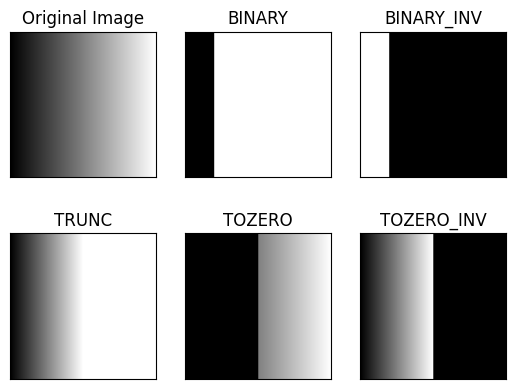

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Loading img
img_path = Path.cwd().parent.parent / "data" / "grayscale.png"
img = cv.imread(img_path, 0)

# Applying different types of thresholding to the image

# cv.THRESH_BINARY: All pixels with intensity greater than the threshold are set to the max value (255).
# The remaining pixels are set to 0
ret, thresh1 = cv.threshold(img, 50, 255, cv.THRESH_BINARY)

# cv.THRESH_BINARY_INV: Inverse of cv.THRESH_BINARY. Pixels with intensity greater than the threshold are set to 0.
# The remaining pixels are set to the max value (255)
ret, thresh2 = cv.threshold(img, 50, 255, cv.THRESH_BINARY_INV)

# cv.THRESH_TRUNC: Pixels with intensity greater than the threshold are set to the threshold value.
# The remaining pixels remain unchanged
ret, thresh3 = cv.threshold(img, 127, 255, cv.THRESH_TRUNC)

# cv.THRESH_TOZERO: Pixels with intensity greater than the threshold remain unchanged.
# The remaining pixels are set to 0
ret, thresh4 = cv.threshold(img, 127, 255, cv.THRESH_TOZERO)

# cv.THRESH_TOZERO_INV: Inverse of cv.THRESH_TOZERO. Pixels with intensity greater than the threshold are set to 0.
# The remaining pixels remain unchanged
ret, thresh5 = cv.threshold(img, 127, 255, cv.THRESH_TOZERO_INV)

# Defining the titles for the plotted images
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']

# Placing all images in a list
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

# Plotting all the images with their respective titles
for i in range(6):
    plt.subplot(2, 3, i+1), plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()



Observe how, using the same approach, we can extract images placed on a uniform background by modifying just one parameter.


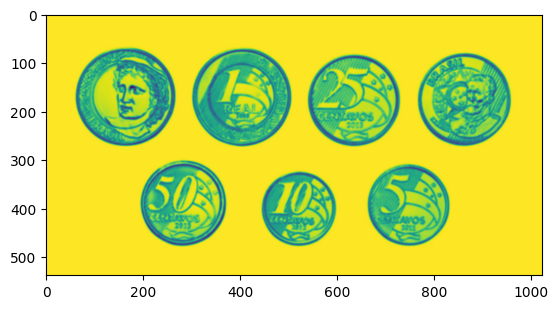

In [9]:
# COINS
image_path = Path.cwd().parent.parent / "data" / "brasil-moedas.jpg"
image = cv.imread(image_path)

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
blurred = cv.GaussianBlur(gray, (7, 7), 0)

plt.imshow(blurred)

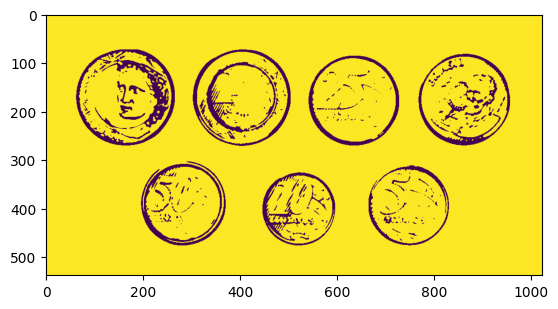

In [10]:
ret, thres = cv.threshold(blurred, 150, 255, cv.THRESH_BINARY)
plt.imshow(thres)

## Adaptive Thresholding

In the previous section, we used a global value as the threshold. However, this may not work well in all cases—for example, if an image has varying lighting conditions across different areas. In such cases, adaptive thresholding can help. Here, the algorithm determines the threshold for each pixel based on a small region around it. As a result, we obtain different thresholds for different regions of the same image, which provides better results for images with uneven illumination.

In addition to the parameters described earlier, the `cv.adaptiveThreshold` method takes three additional input parameters:

The `adaptiveMethod` decides how the threshold value is calculated:

- `cv.ADAPTIVE_THRESH_MEAN_C`: The threshold value is the mean of the neighborhood area minus the constant `C`.
- `cv.ADAPTIVE_THRESH_GAUSSIAN_C`: The threshold value is the weighted sum (Gaussian) of the neighborhood values minus the constant `C`.

The `blockSize` determines the size of the neighborhood area, and `C` is a constant subtracted from the mean or weighted sum of the neighborhood pixels.

The code below compares global thresholding and adaptive thresholding for an image with variable lighting:


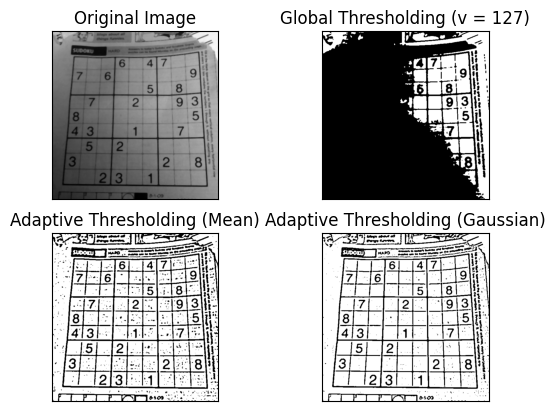

In [11]:
# Reading the image in grayscale
image_path = Path.cwd().parent.parent / "data" / "sudoku.png"
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

# Applying a median filter with kernel size 5 to reduce noise
img = cv.medianBlur(img, 5)

# Applying global thresholding with a threshold value of 127
ret, th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)

# Applying adaptive thresholding using the mean of the neighborhood area
th2 = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2)

# Applying adaptive thresholding using a Gaussian-weighted sum of the neighborhood area
th3 = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

# Titles for each image
titles = ['Original Image', 'Global Thresholding (v = 127)', 'Adaptive Thresholding (Mean)', 'Adaptive Thresholding (Gaussian)']

# List of processed images
images = [img, th1, th2, th3]

# Creating subplots to display the images
for i in range(4):
    plt.subplot(2, 2, i+1), plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

# Displaying the images
plt.show()
